# Run on google colab only

This notebook is optimized for Google Colab

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!ln -sf '/content/drive/MyDrive/svm_gridsearch' '/content/svm_gridsearch'

Mounted at /content/drive


In [2]:
!nvidia-smi

Mon May 11 13:01:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   35C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
%load_ext cuml.accel
%load_ext cudf.pandas

In [4]:
!pip install optuna -qqq && echo "successfully installed optuna"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.5 MB/s eta 0:00:00
successfully installed optuna


# Define constants

In [2]:
from scipy.stats import loguniform

CLEAN_FEATURES_PATH = "./svm_gridsearch/opus-training.npz"
NOISY_FEATURES_PATH = "./svm_gridsearch/opus-evaluation.npz"
MODEL_SAVE_PATH = "./models"
STORAGE_NAME = "sqlite:///svm_gridsearch/svm_tuning.db"
STUDY_NAME = "RBF_SVM_Tuning-RandomizedSearchCV"
STUDY_OVERRIDE = True
RANDOM_STATE = 42
SVM_TEST_SIZE = 0.1
SVM_CV_FOLDS = 5
SVM_CV_N_ITER = 20
SEARCH_C = [0.1, 1.0, 10.0, 100.0, 1000.0]
SEARCH_GAMMA = [0.000001, 0.00001, 0.0001, 0.001] #  (1 / 40608) = 0.000025
SEARCH_N_TRIALS = 10 # continues from existing search

import os
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
SVM_MODEL_PATH = os.path.join(MODEL_SAVE_PATH, 'model.pkl')
SVM_SCALER_PATH = os.path.join(MODEL_SAVE_PATH, 'scaler.pkl')
SVM_ENCODER_PATH = os.path.join(MODEL_SAVE_PATH, 'label_encoder.pkl')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
import random
import numpy as np
import cupy as cp
import tensorflow as tf

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
cp.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


# Hyperparameter Tuning

## Load features

In [ ]:
import numpy as np
import cupy as cp

# Load the NPZ file using numpy to handle string labels
with np.load(CLEAN_FEATURES_PATH) as data:
    # Features are numerical, so we can move them to GPU immediately
    features = cp.array(data['features'])
    # Labels are strings; keep them as numpy for encoding in the next step
    labels = data['labels']

print(f"Loaded features shape: {features.shape}")
print(f"Loaded labels shape:   {labels.shape}")

Loaded features shape: (7200, 216, 188)
Loaded labels shape:   (7200,)


## Split data

In [ ]:
from cuml.model_selection import train_test_split
from cuml.preprocessing import LabelEncoder, StandardScaler

# Flatten 2D CQT features to 1D for SVM input
features_flat = features.reshape(features.shape[0], -1)

# Encode labels
svm_label_encoder = LabelEncoder()
svm_encoded_labels = svm_label_encoder.fit_transform(labels)

# Train/test split on the sampled data
X_svm_train, X_svm_test, y_svm_train, y_svm_test = train_test_split(
    features_flat,
    svm_encoded_labels,
    test_size=SVM_TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=svm_encoded_labels,
)

# Scale features
scaler = StandardScaler()

X_svm_train = scaler.fit_transform(X_svm_train)
X_svm_train = cp.asarray(X_svm_train)
y_svm_train = cp.asarray(y_svm_train)

X_svm_test = scaler.transform(X_svm_test)
X_svm_test = cp.asarray(X_svm_test)
y_svm_test = cp.asarray(y_svm_test)

print(f"Original dataset size: {len(features_flat)}")
print(f"X_svm_train shape:      {X_svm_train.shape}")
print(f"X_svm_test shape:       {X_svm_test.shape}")
print(f"Number of classes:      {len(svm_label_encoder.classes_)}")

Original dataset size: 7200
X_svm_train shape:      (6480, 40608)
X_svm_test shape:       (720, 40608)
Number of classes:      36


## GridSearchCV

In [ ]:
import optuna
import cupy as cp
import pandas as pd
from cuml.svm import SVC
from cuml.metrics import accuracy_score
from cuml.model_selection import StratifiedKFold
from cuml.preprocessing import StandardScaler
from datetime import datetime

def objective(trial):
    trial_start_time = datetime.now().replace(microsecond=0)

    # Pick from the discrete powers of 10
    c_val = trial.suggest_categorical("C", SEARCH_C)
    gamma_val = trial.suggest_categorical("gamma", SEARCH_GAMMA)

    # Instantiate the cuML model
    model = SVC(kernel='rbf', C=c_val, gamma=gamma_val, random_state=RANDOM_STATE)

    # Cross-Validation
    skf = StratifiedKFold(n_splits=SVM_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    print(f"Trial {trial.number} - C = {c_val} gamma = {gamma_val}")

    scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_svm_train, y_svm_train), 1):
        fold_start_time = datetime.now().replace(microsecond=0)
        X_tr, X_val = X_svm_train[train_idx], X_svm_train[val_idx]
        y_tr, y_val = y_svm_train[train_idx], y_svm_train[val_idx]

        print(f"  Trial {trial.number} - Fold {fold_idx}: Fitting...")
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        score = accuracy_score(y_val, preds)
        scores.append(score)

        fold_time = datetime.now().replace(microsecond=0) - fold_start_time
        print(f"  Trial {trial.number} - Fold {fold_idx}: Accuracy = {score:.4f} ({fold_time})")

    result = sum(scores) / len(scores)
    trial_time = datetime.now().replace(microsecond=0) - trial_start_time
    print(f"  Trial {trial.number} - C = {c_val} gamma = {gamma_val}: Result = {result} ({trial_time})")

    return result

if STUDY_OVERRIDE:
  try:
      optuna.delete_study(study_name=STUDY_NAME, storage=STORAGE_NAME)
      print(f"Override study '{STUDY_NAME}' to apply new parameters.")
  except KeyError:
      pass

# Create or load the Optuna study with RandomSampler
study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=STORAGE_NAME,
    direction="maximize",
    load_if_exists=True,
    sampler=optuna.samplers.RandomSampler(seed=RANDOM_STATE)
)

print(f"Study {STUDY_NAME} is now persistent at {STORAGE_NAME}")

# Run the search
print("Optimizing objective...")
study.optimize(objective, n_trials=SEARCH_N_TRIALS, show_progress_bar=True, gc_after_trial=True)

# Tie-breaking for best parameters
df = study.trials_dataframe()
best_score = df['value'].max()
tied_trials = df[df['value'] == best_score]
best_configuration = tied_trials.sort_values(by=['params_C', 'params_gamma']).iloc[0]

print(f"Maximum CV Accuracy: {best_score:.6f}")
print(f"Optimal C: {best_configuration['params_C']:.6f}")
print(f"Optimal Gamma: {best_configuration['params_gamma']:.6f}")


[I 2026-05-08 07:20:04,608] A new study created in RDB with name: RBF_SVM_Tuning-RandomizedSearchCV


Override study 'RBF_SVM_Tuning-RandomizedSearchCV' to apply new parameters.
Study RBF_SVM_Tuning-RandomizedSearchCV is now persistent at sqlite:///svm_gridsearch/svm_tuning.db
Optimizing objective...


  0%|          | 0/10 [00:00<?, ?it/s]

Trial 0 - C = 1.0 gamma = 0.0001
  Trial 0 - Fold 1: Fitting...
  Trial 0 - Fold 1: Accuracy = 0.9383 (0:03:27)
  Trial 0 - Fold 2: Fitting...
  Trial 0 - Fold 2: Accuracy = 0.9444 (0:03:30)
  Trial 0 - Fold 3: Fitting...
  Trial 0 - Fold 3: Accuracy = 0.9429 (0:03:30)
  Trial 0 - Fold 4: Fitting...
  Trial 0 - Fold 4: Accuracy = 0.9468 (0:03:29)
  Trial 0 - Fold 5: Fitting...
  Trial 0 - Fold 5: Accuracy = 0.9414 (0:03:28)
  Trial 0 - C = 1.0 gamma = 0.0001: Result = 0.9427469135802469 (0:17:24)
[I 2026-05-08 07:37:29,404] Trial 0 finished with value: 0.9427469135802469 and parameters: {'C': 1.0, 'gamma': 0.0001}. Best is trial 0 with value: 0.9427469135802469.
Trial 1 - C = 10.0 gamma = 0.001
  Trial 1 - Fold 1: Fitting...
  Trial 1 - Fold 1: Accuracy = 0.1890 (0:03:42)
  Trial 1 - Fold 2: Fitting...
  Trial 1 - Fold 2: Accuracy = 0.1906 (0:03:42)
  Trial 1 - Fold 3: Fitting...
  Trial 1 - Fold 3: Accuracy = 0.1759 (0:03:42)
  Trial 1 - Fold 4: Fitting...
  Trial 1 - Fold 4: Accuracy

## Checkpoint

In [ ]:
print(f"Maximum CV Accuracy: {best_score}")
print(f"Optimal C (Tie-broken): {best_configuration['params_C']}")
print(f"Optimal Gamma (Tie-broken): {best_configuration['params_gamma']}")

Maximum CV Accuracy: 0.9958333333333333
Optimal C (Tie-broken): 0.1
Optimal Gamma (Tie-broken): 1e-06


# Train with sklearn for compatibility

## Prepare

In [ ]:
# Use the values from the best tuned hyperparameter
OPTIMAL_C = 0.100000
OPTIMAL_GAMMA = 0.000001

In [ ]:
import numpy as np

with np.load(CLEAN_FEATURES_PATH) as data:
    features = data['features']
    labels = data['labels']

print(f"Loaded features shape: {features.shape}")
print(f"Loaded labels shape:   {labels.shape}")

Loaded features shape: (7200, 216, 188)
Loaded labels shape:   (7200,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Flatten 2D CQT features to 1D for SVM input
features_flat = features.reshape(features.shape[0], -1)

# Encode labels
svm_label_encoder = LabelEncoder()
svm_encoded_labels = svm_label_encoder.fit_transform(labels)

# Train/test split on the sampled data
X_svm_train, X_svm_test, y_svm_train, y_svm_test = train_test_split(
    features_flat,
    svm_encoded_labels,
    test_size=SVM_TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=svm_encoded_labels,
)

# Scale features
scaler = StandardScaler()

X_svm_train = scaler.fit_transform(X_svm_train)
X_svm_test = scaler.transform(X_svm_test)

print(f"Original dataset size:  {len(features_flat)}")
print(f"X_svm_train shape:      {X_svm_train.shape}")
print(f"X_svm_test shape:       {X_svm_test.shape}")
print(f"Number of classes:      {len(svm_label_encoder.classes_)}")

Original dataset size:  7200
X_svm_train shape:      (6480, 40608)
X_svm_test shape:       (720, 40608)
Number of classes:      36


## Train final model

In [ ]:
from sklearn.svm import SVC

best_svm_model = SVC(
    kernel='rbf',
    C=OPTIMAL_C,
    gamma=OPTIMAL_GAMMA,
    random_state=RANDOM_STATE
)
best_svm_model.fit(X_svm_train, y_svm_train)

SVC(C=0.1, gamma=1e-06, random_state=42)

## Evaluate best model

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_svm_pred = best_svm_model.predict(X_svm_test)

gs_accuracy = accuracy_score(y_svm_test, y_svm_pred)
print(f"Test Accuracy (best model): {gs_accuracy}")

report_gs = classification_report(y_svm_test, y_svm_pred, target_names=svm_label_encoder.classes_)
print("\nClassification Report:\n", report_gs)

Test Accuracy (best model): 0.9986111111111111

Classification Report:
                  precision    recall  f1-score   support

A#_diminished_4       0.95      1.00      0.98        20
     A#_major_4       1.00      1.00      1.00        20
     A#_minor_4       1.00      1.00      1.00        20
 A_diminished_4       1.00      1.00      1.00        20
      A_major_4       1.00      1.00      1.00        20
      A_minor_4       1.00      1.00      1.00        20
 B_diminished_4       1.00      1.00      1.00        20
      B_major_4       1.00      1.00      1.00        20
      B_minor_4       1.00      1.00      1.00        20
C#_diminished_4       1.00      1.00      1.00        20
     C#_major_4       1.00      1.00      1.00        20
     C#_minor_4       1.00      1.00      1.00        20
 C_diminished_4       1.00      0.95      0.97        20
      C_major_4       1.00      1.00      1.00        20
      C_minor_4       1.00      1.00      1.00        20
D#_diminished_4

## Confusion Matrix

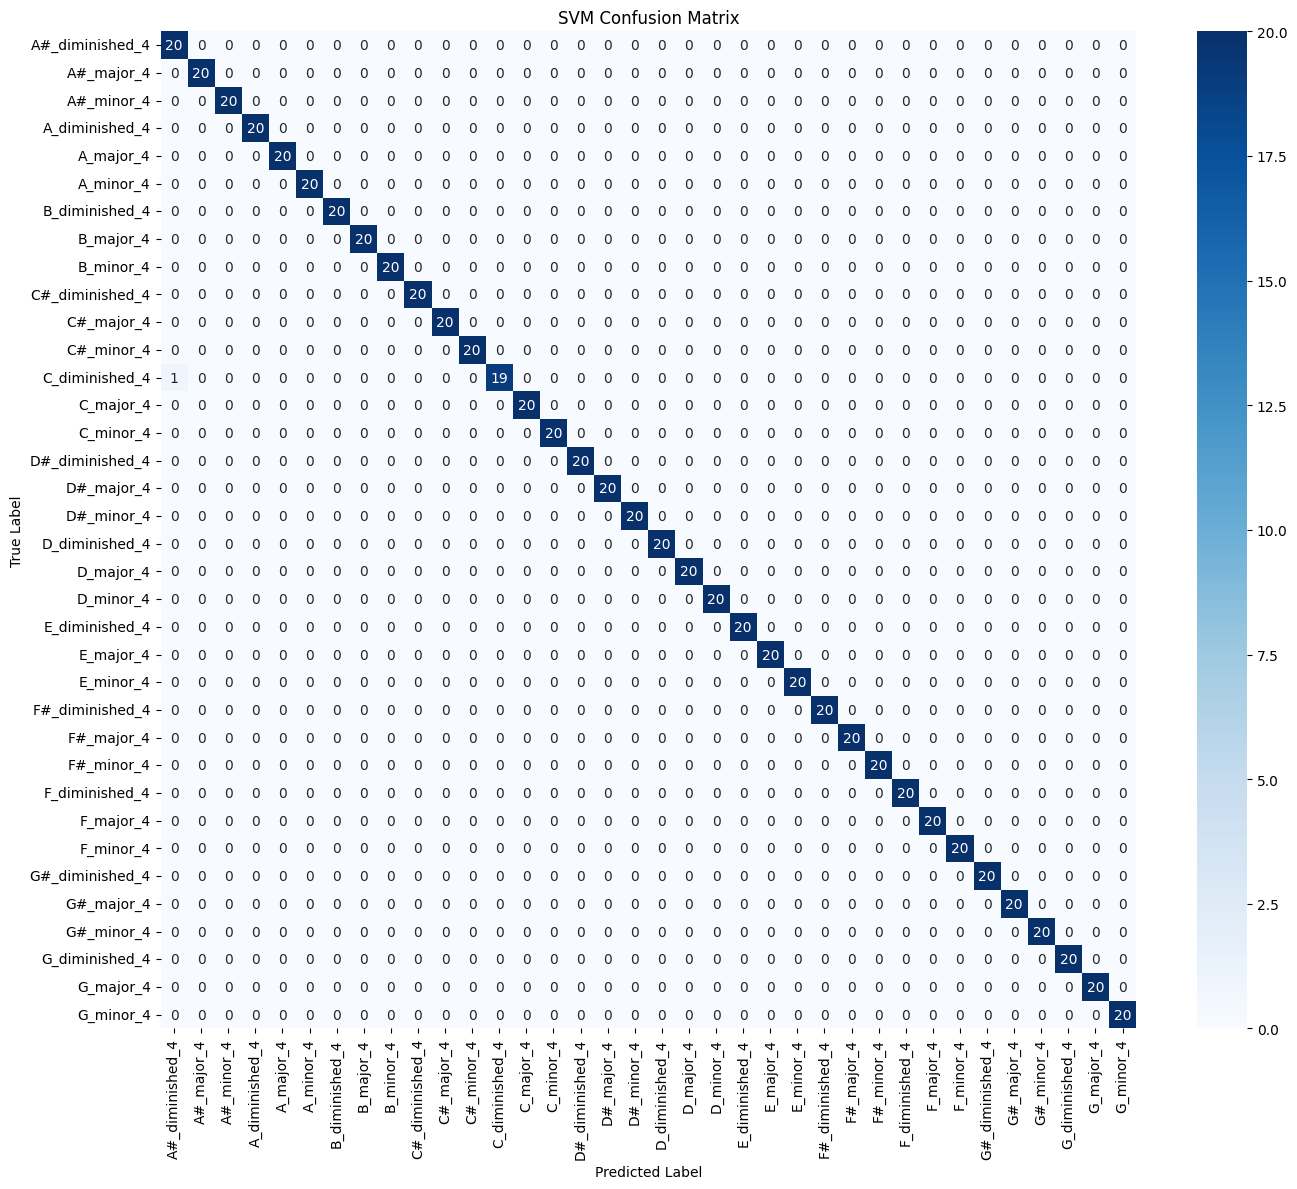

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_svm_test, y_svm_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_label_encoder.classes_, yticklabels=svm_label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'SVM Confusion Matrix')
plt.tight_layout()
plt.show()

## Save SVM Model

In [ ]:
import joblib

joblib.dump(best_svm_model, SVM_MODEL_PATH)
joblib.dump(scaler, SVM_SCALER_PATH)
joblib.dump(svm_label_encoder, SVM_ENCODER_PATH)

print(f"SVM model saved to {MODEL_SAVE_PATH}")

SVM model saved to ./models


In [ ]:
!zip svm_models.zip models/*

  adding: models/label_encoder.pkl (deflated 83%)
  adding: models/model.pkl (deflated 48%)
  adding: models/scaler.pkl (deflated 6%)


In [ ]:
from google.colab import files
files.download('svm_models.zip')

# K-Fold Cross-Validation

## Prepare data

In [3]:
# Use the values from the best tuned hyperparameter
OPTIMAL_C = 0.100000
OPTIMAL_GAMMA = 0.000001

import numpy as np
import cupy as cp

with np.load(CLEAN_FEATURES_PATH) as data:
    features = cp.array(data['features'])
    labels = data['labels']

print(f"Loaded features shape: {features.shape}")
print(f"Loaded labels shape:   {labels.shape}")

Loaded features shape: (7200, 216, 188)
Loaded labels shape:   (7200,)


In [4]:
from cuml.preprocessing import LabelEncoder

# Flatten 2D CQT features to 1D for SVM input
features_flat = features.reshape(features.shape[0], -1)

# Encode labels
svm_label_encoder = LabelEncoder()
svm_encoded_labels = svm_label_encoder.fit_transform(labels)

print(f"Original dataset size:  {len(features_flat)}")
print(f"Features flat shape:    {features_flat.shape}")
print(f"Encoded labels shape:   {svm_encoded_labels.shape}")
print(f"Number of classes:      {len(svm_label_encoder.classes_)}")

Original dataset size:  7200
Features flat shape:    (7200, 40608)
Encoded labels shape:   (7200,)
Number of classes:      36


## Cross validation

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from cuml.model_selection import StratifiedKFold
from cuml.preprocessing import StandardScaler
from cuml.svm import SVC
from cuml.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
import gc
import cupy as cp
from datetime import datetime
import os
import pickle

# Ensure labels are int32 for cuML metrics compatibility
svm_encoded_labels = svm_encoded_labels.astype('int32')

# 1. CROSS VALIDATION PROCESS
# Note: The dataset has 200 samples per class.
# With 5 folds (SVM_CV_FOLDS=5), each validation fold gets 20% of the data, which is 40 samples per class.
# The test_size=0.1 used earlier does not apply to this K-Fold splitting logic.
print("Starting K-Fold Cross Validation...")

skf = StratifiedKFold(n_splits=SVM_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

CHECKPOINT_FILE = "cv_checkpoint.pkl"

if os.path.exists(CHECKPOINT_FILE):
    print("Loading checkpoint...")
    with open(CHECKPOINT_FILE, "rb") as f:
        checkpoint_data = pickle.load(f)
        fold_metrics = checkpoint_data['fold_metrics']
        confusion_matrices = checkpoint_data['confusion_matrices']
    last_completed_fold = max([m['Fold'] for m in fold_metrics]) if fold_metrics else 0
    print(f"Resuming from fold {last_completed_fold + 1}")
else:
    fold_metrics = []
    confusion_matrices = []
    last_completed_fold = 0

# Convert classes to standard format for sklearn compatibility
class_names = svm_label_encoder.classes_.to_pandas()

for fold, (train_idx, val_idx) in enumerate(skf.split(features_flat, svm_encoded_labels), 1):
    if fold <= last_completed_fold:
        print(f"\n{'-'*20} Fold {fold} {'-'*20}")
        print("Skipping (already completed from checkpoint).")
        continue

    fold_start_time = datetime.now().replace(microsecond=0)
    print(f"\n{'-'*20} Fold {fold} {'-'*20}")
    X_train_cv, X_val_cv = features_flat[train_idx], features_flat[val_idx]
    y_train_cv, y_val_cv = svm_encoded_labels[train_idx], svm_encoded_labels[val_idx]

    # Scale data (fit on training fold only to prevent leakage)
    cv_scaler = StandardScaler()
    X_train_cv = cv_scaler.fit_transform(X_train_cv)
    X_val_cv = cv_scaler.transform(X_val_cv)

    # Train Model
    cv_model = SVC(
        kernel='rbf',
        C=OPTIMAL_C,
        gamma=OPTIMAL_GAMMA,
        random_state=RANDOM_STATE,
        cache_size=512
    )
    cv_model.fit(X_train_cv, y_train_cv)
    fold_duration = datetime.now().replace(microsecond=0) - fold_start_time
    print(f"Train Duration: {fold_duration}")

    y_pred_cv = cv_model.predict(X_val_cv)
    acc = accuracy_score(y_val_cv, y_pred_cv)
    cm = confusion_matrix(y_val_cv, y_pred_cv)

    # Explicitly move to CPU ONLY for the classification report using cp.asnumpy
    y_val_cpu = cp.asnumpy(y_val_cv)
    y_pred_cpu = cp.asnumpy(y_pred_cv)
    cm_cpu = cp.asnumpy(cm)  # if hasattr(cm, 'get') or isinstance(cm, cp.ndarray) else cm # ensuring CPU format for saving

    # Call 1: Get the report as a dictionary to programmatically extract F1 scores
    report_dict = classification_report(y_val_cpu, y_pred_cpu, target_names=class_names, output_dict=True)

    fold_metrics.append({
        'Fold': fold,
        'Accuracy': acc,
        'Macro F1': report_dict['macro avg']['f1-score'],
        'Weighted F1': report_dict['weighted avg']['f1-score']
    })
    confusion_matrices.append(cm_cpu)

    # Save Checkpoint
    with open(CHECKPOINT_FILE, "wb") as f:
        pickle.dump({
            'fold_metrics': fold_metrics,
            'confusion_matrices': confusion_matrices
        }, f)
    print("Checkpoint saved.")

    fold_duration = datetime.now().replace(microsecond=0) - fold_start_time

    print(f"Accuracy: {acc:.4f}")
    print(f"Fold Duration: {fold_duration}")
    print("Classification Report:")
    # Call 2: Get the report as a formatted string to print to the console
    print(classification_report(y_val_cpu, y_pred_cpu, target_names=class_names))

    # Explicitly free up memory
    del X_train_cv, X_val_cv, y_train_cv, y_val_cv, cv_model, cv_scaler, y_pred_cv, cm, cm_cpu, y_val_cpu, y_pred_cpu
    gc.collect()

    # Force CuPy to release cached VRAM blocks back to the OS
    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()


Starting K-Fold Cross Validation...

-------------------- Fold 1 --------------------
Train Duration: 0:01:22
Checkpoint saved.
Accuracy: 0.9958
Fold Duration: 0:03:23
Classification Report:
                 precision    recall  f1-score   support

A#_diminished_4       0.93      1.00      0.96        40
     A#_major_4       0.98      1.00      0.99        40
     A#_minor_4       1.00      0.97      0.99        40
 A_diminished_4       1.00      1.00      1.00        40
      A_major_4       1.00      1.00      1.00        40
      A_minor_4       1.00      1.00      1.00        40
 B_diminished_4       1.00      1.00      1.00        40
      B_major_4       1.00      1.00      1.00        40
      B_minor_4       1.00      1.00      1.00        40
C#_diminished_4       1.00      1.00      1.00        40
     C#_major_4       1.00      1.00      1.00        40
     C#_minor_4       1.00      1.00      1.00        40
 C_diminished_4       1.00      0.93      0.96        40
      C_ma

## Plot


=== Cross Validation Summary ===
   Fold  Accuracy  Macro F1  Weighted F1
0     1  0.995833  0.995830     0.995830
1     2  0.995833  0.995771     0.995771
2     3  0.998611  0.998611     0.998611
3     4  0.992361  0.992296     0.992296
4     5  0.995833  0.995823     0.995823

Mean Accuracy: 0.99569444 (+/- 0.00221788)


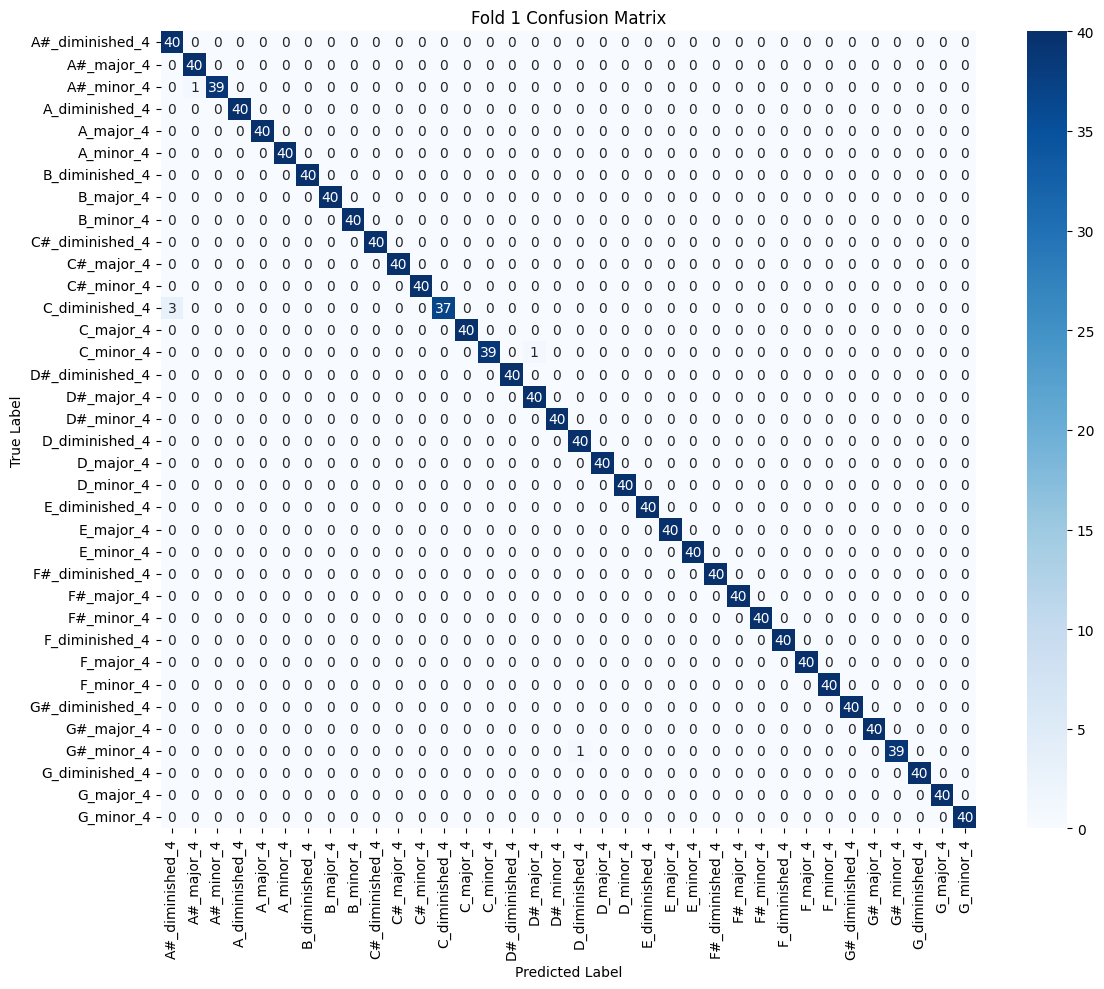

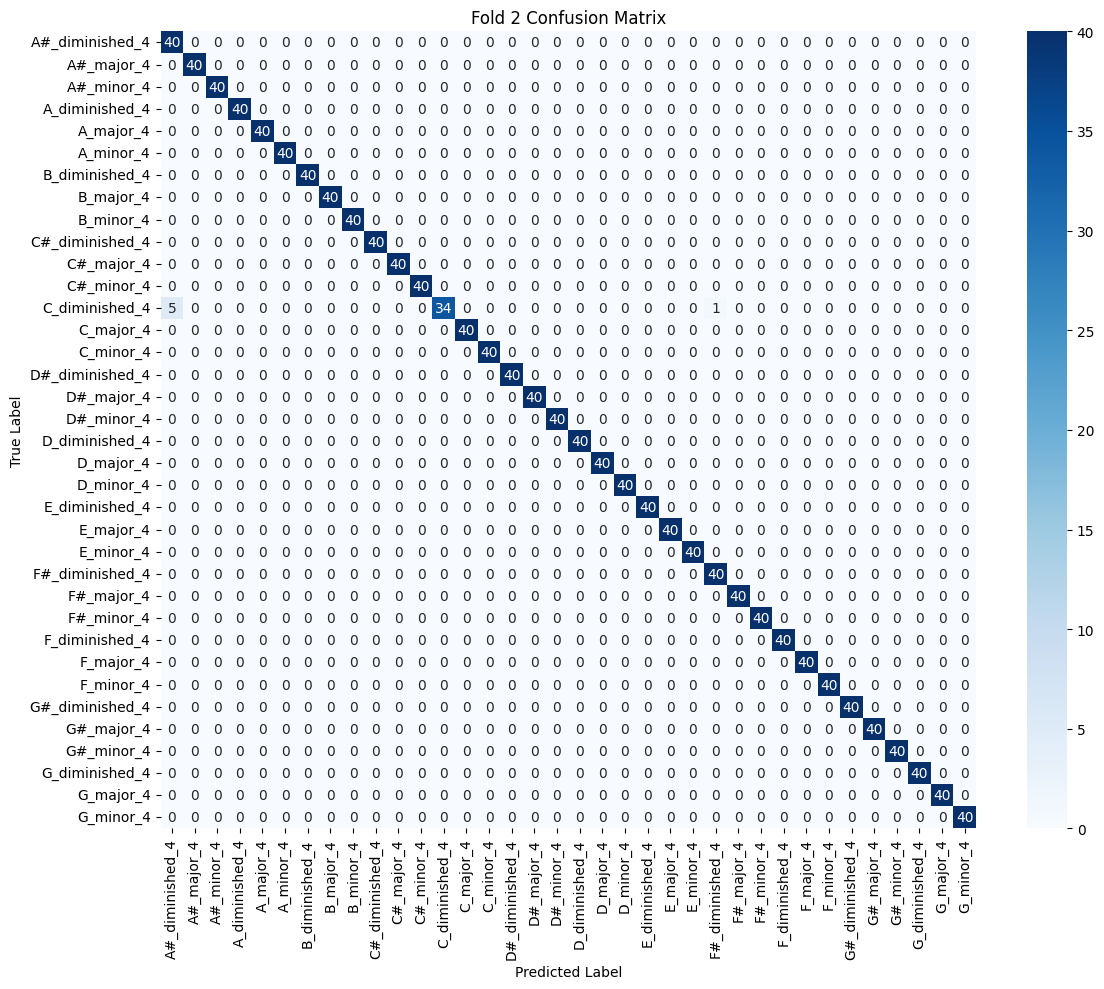

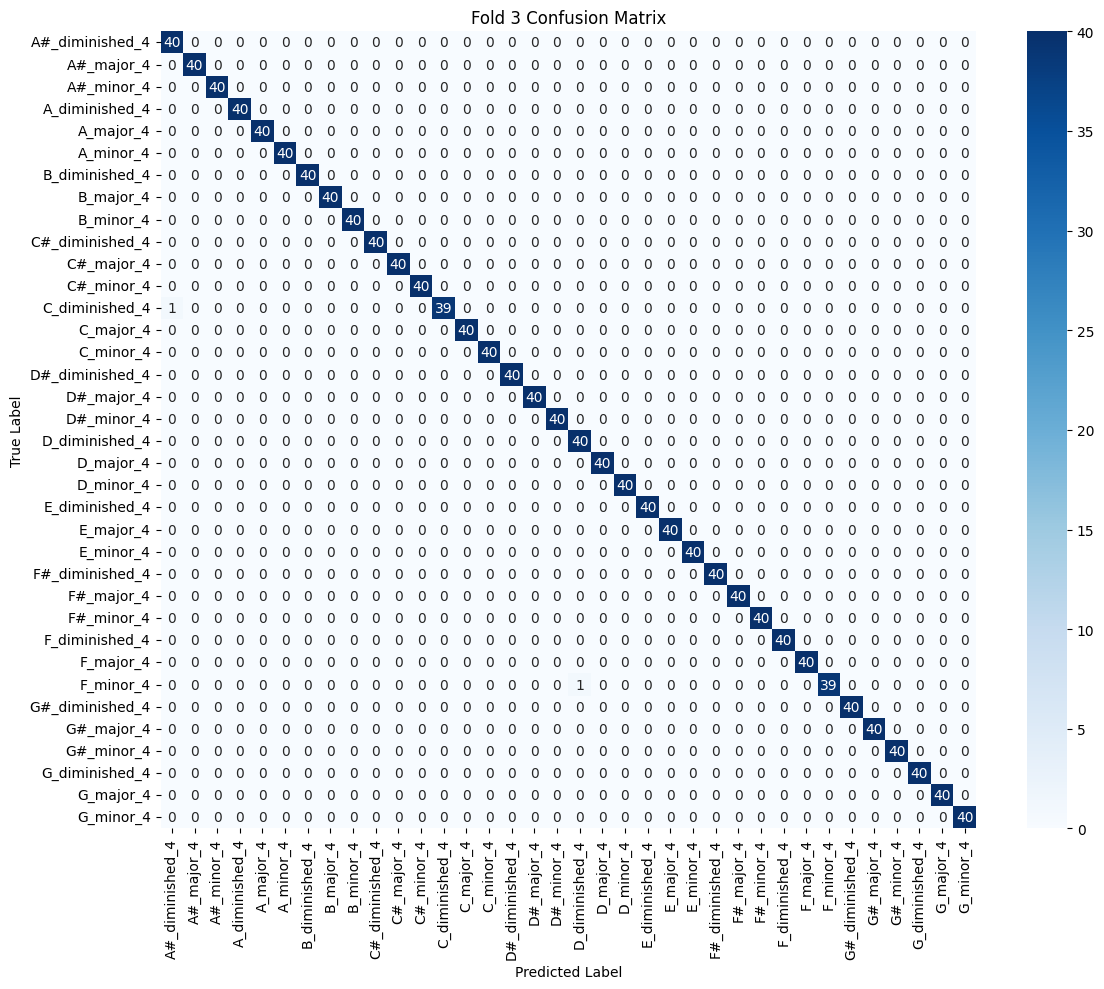

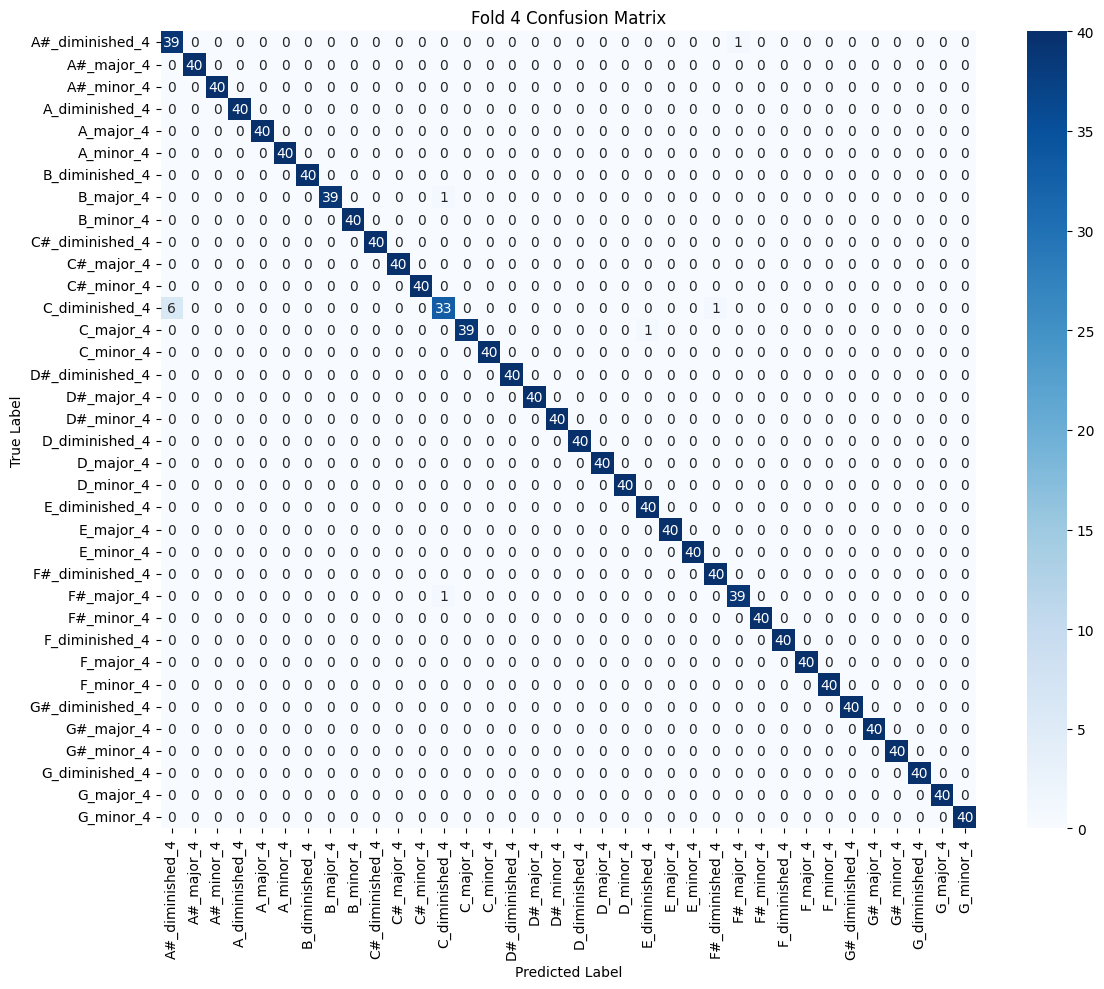

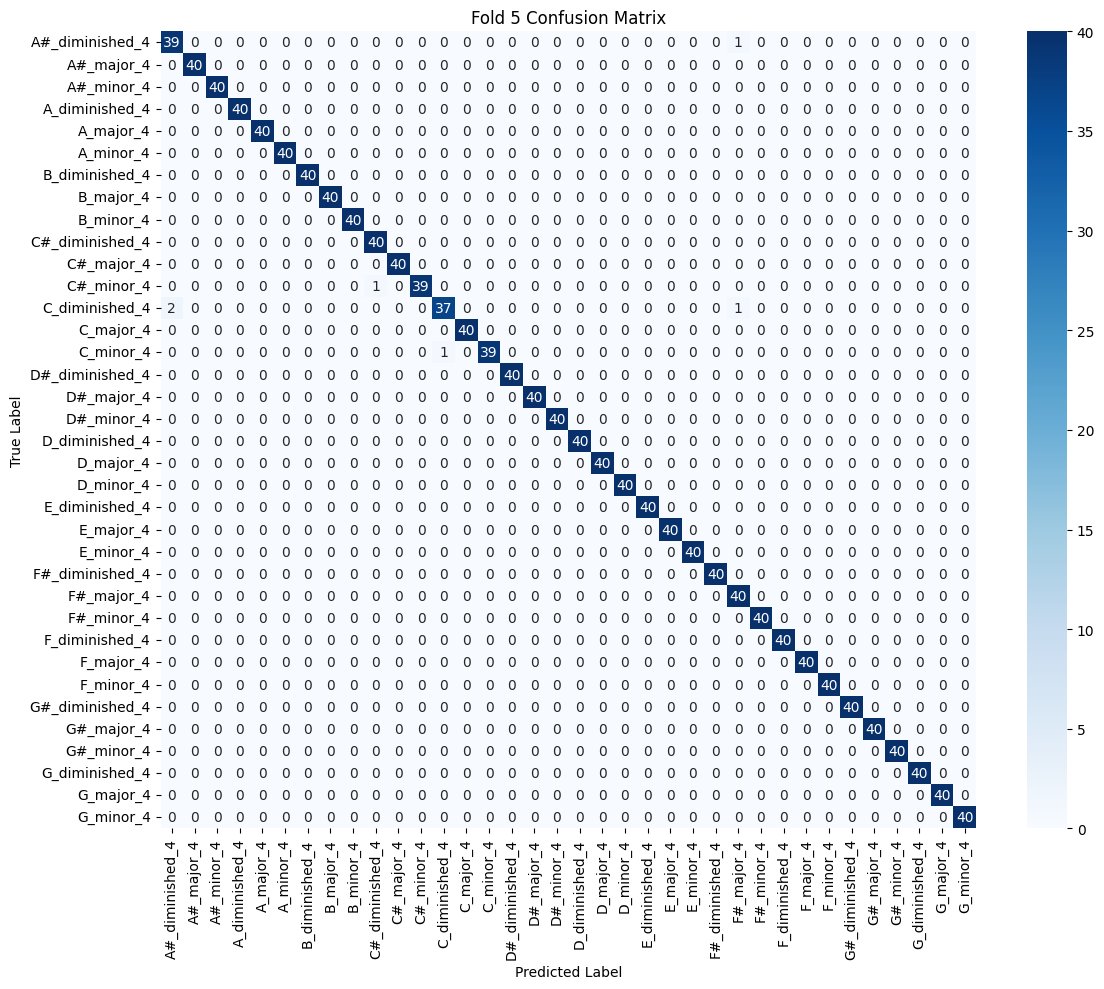

In [12]:
# 2. ACCURACY TABLES & SUMMARY METRICS
print("\n" + "="*40)
print("=== Cross Validation Summary ===")
print("="*40)
metrics_df = pd.DataFrame(fold_metrics)
print(metrics_df)
print(f"\nMean Accuracy: {metrics_df['Accuracy'].mean():.8f} (+/- {metrics_df['Accuracy'].std():.8f})")

# 3. PLOT CONFUSION MATRICES
for i, cm in enumerate(confusion_matrices):
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, cmap='Blues', cbar=True,
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Fold {i+1} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()


# Test Noisy

## Load Model & Noisy Features

In [ ]:
import joblib

svm_model = joblib.load(SVM_MODEL_PATH)
svm_scaler = joblib.load(SVM_SCALER_PATH)
svm_label_encoder = joblib.load(SVM_ENCODER_PATH)
noisy_data = np.load(NOISY_FEATURES_PATH)
noisy_features = noisy_data['features']
noisy_labels = noisy_data['labels']

print(f"SVM model loaded from {MODEL_SAVE_PATH}")
print(f"Classes: {svm_label_encoder.classes_}")

SVM model loaded from ./models
Classes: ['A#_diminished_4' 'A#_major_4' 'A#_minor_4' 'A_diminished_4' 'A_major_4'
 'A_minor_4' 'B_diminished_4' 'B_major_4' 'B_minor_4' 'C#_diminished_4'
 'C#_major_4' 'C#_minor_4' 'C_diminished_4' 'C_major_4' 'C_minor_4'
 'D#_diminished_4' 'D#_major_4' 'D#_minor_4' 'D_diminished_4' 'D_major_4'
 'D_minor_4' 'E_diminished_4' 'E_major_4' 'E_minor_4' 'F#_diminished_4'
 'F#_major_4' 'F#_minor_4' 'F_diminished_4' 'F_major_4' 'F_minor_4'
 'G#_diminished_4' 'G#_major_4' 'G#_minor_4' 'G_diminished_4' 'G_major_4'
 'G_minor_4']


## Test SVM Model

SVM Test Accuracy on Noisy Dataset: 0.027778

Classification Report:
                  precision    recall  f1-score   support

A#_diminished_4       0.00      0.00      0.00       100
     A#_major_4       0.00      0.00      0.00       100
     A#_minor_4       0.00      0.00      0.00       100
 A_diminished_4       0.00      0.00      0.00       100
      A_major_4       0.00      0.00      0.00       100
      A_minor_4       0.00      0.00      0.00       100
 B_diminished_4       0.00      0.00      0.00       100
      B_major_4       0.00      0.00      0.00       100
      B_minor_4       0.00      0.00      0.00       100
C#_diminished_4       0.00      0.00      0.00       100
     C#_major_4       0.00      0.00      0.00       100
     C#_minor_4       0.00      0.00      0.00       100
 C_diminished_4       0.03      1.00      0.05       100
      C_major_4       0.00      0.00      0.00       100
      C_minor_4       0.00      0.00      0.00       100
D#_diminished_4  

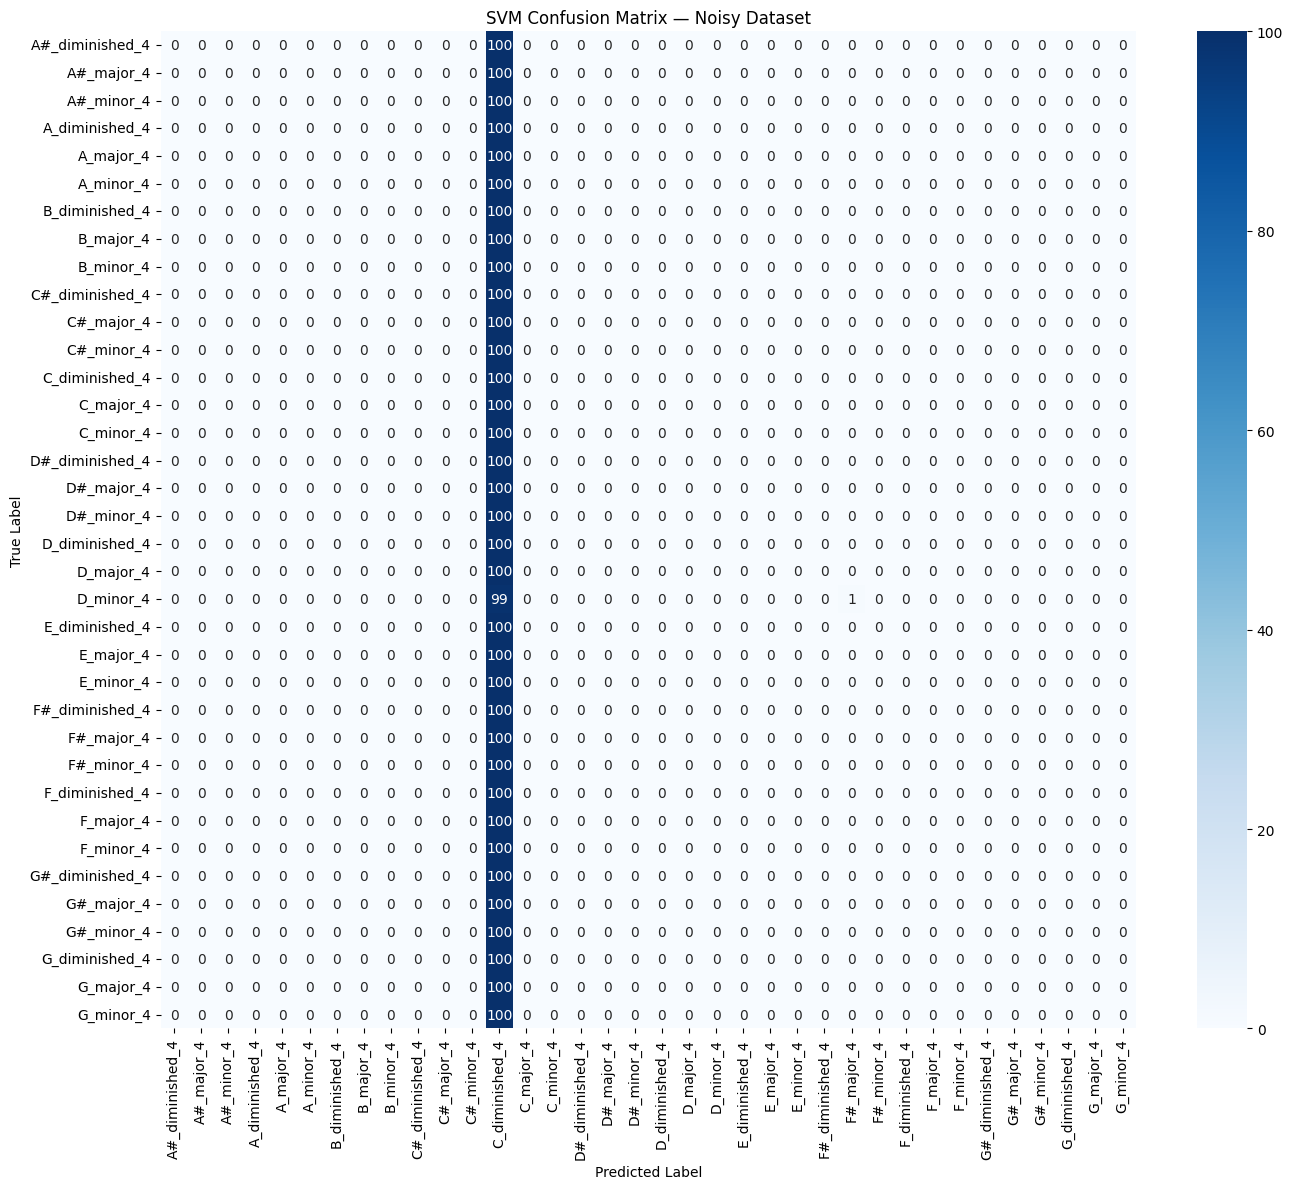

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Flatten and scale noisy features the same way as training data
noisy_features_flat   = noisy_features.reshape(noisy_features.shape[0], -1)
noisy_features_scaled = svm_scaler.transform(noisy_features_flat)

# Encode noisy labels using the loaded label encoder
noisy_svm_encoded = svm_label_encoder.transform(noisy_labels)

# Predict
y_noisy_pred = svm_model.predict(noisy_features_scaled)

# Accuracy & report
noisy_svm_accuracy = accuracy_score(noisy_svm_encoded, y_noisy_pred)
print(f"SVM Test Accuracy on Noisy Dataset: {noisy_svm_accuracy:.6f}")

svm_class_labels = svm_label_encoder.classes_
report_noisy_svm = classification_report(noisy_svm_encoded, y_noisy_pred, target_names=svm_class_labels, zero_division=0)
print("\nClassification Report:\n", report_noisy_svm)

# Confusion matrix
cm_noisy_svm = confusion_matrix(noisy_svm_encoded, y_noisy_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_noisy_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_class_labels, yticklabels=svm_class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Confusion Matrix — Noisy Dataset')
plt.tight_layout()
plt.show()